# Chapter 15: What an Agent Should Remember: Retrieval, Compression, and Experience

A controller remembers an earlier approval. The text is relevant, concise, and easy to retrieve. It can still be the wrong memory to use if the approval belongs to an older document version. Memory quality therefore includes authority and freshness, not only similarity or token efficiency.

This notebook solves a small declared retrieval allocation. Records consume tokens and contribute additive decision value, but stale records and invalid version-bound authority are excluded first. A separate compression diagnostic checks whether the preferred action survives. The example intentionally gives an obsolete approval a very attractive value, making it impossible to confuse a high relevance score with current permission.

**Outcome:** Choose fresh valid records and inspect action preservation under compression.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

For record i, let t_i be token cost, v_i declared decision value, and x_i in{0,1} retrieval status. The finite allocation maximizes sum_i v_i x_i subject to sum_i t_i x_i<=B. Freshness requires now-timestamp_i<=ttl_i. An authority-bearing record also requires its version to equal the current version.

The code uses exact zero-one knapsack dynamic programming over integer budgets. Descending budget updates prevent the same record from being selected repeatedly. Its frontier gives the greatest eligible additive value at every budget from zero to B. These values are supplied judgments, not embedding similarity or empirically learned information gain.

For compression, the implementation compares argmax_a Q_original(a) with argmax_a Q_compressed(a). Equal choices mean this particular decision is preserved. They do not imply the compressed memory retains every fact or supports every future task. Ties follow list order, so a genuine decision-preservation claim should also inspect whether a meaningful action gap remains.

## A calculation you can run

Supply records with token counts, value, timestamps, time-to-live, authority flags, and version identifiers. The function checks numeric domains and rejects a timestamp later than now. It constructs freshness and authority validity before allocating budget. Invalid records remain visible in the returned table rather than disappearing without explanation.

The plot shows the eligible retrieval frontier against token budget. The metrics identify selected and excluded records, used tokens, and compression choices. In the changed case reduce the budget and alter the compressed action values. Predict which record remains affordable and whether the action still matches. The two interventions address separate questions, so report both rather than attributing the entire change to memory quality.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 15
inputs = {'budget': 6,
 'now': 10,
 'current_version': 'v2',
 'records': [{'id': 'review-v2',
              'tokens': 4,
              'decision_value': 8,
              'timestamp': 9,
              'ttl': 3,
              'authority': True,
              'version': 'v2'},
             {'id': 'summary',
              'tokens': 2,
              'decision_value': 3,
              'timestamp': 8,
              'ttl': 5,
              'authority': False,
              'version': 'v1'},
             {'id': 'old-review',
              'tokens': 1,
              'decision_value': 100,
              'timestamp': 9,
              'ttl': 3,
              'authority': True,
              'version': 'v1'}],
 'original_action_values': [4, 6],
 'compressed_action_values': [3, 5]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 15: memory-budget
Which memories deserve a limited retrieval budget, and does compression preserve the decision?
Evidence: constructed teaching example

Calculated quantities:
{
  "retrieved_ids": [
    "review-v2",
    "summary"
  ],
  "retrieval_value": 11.0,
  "tokens_used": 6,
  "excluded_ids": [
    "old-review"
  ],
  "compression_preserves_action": true,
  "original_action": 1,
  "compressed_action": 1
}

Interpretation:
Retrieval optimizes declared decision value among records that satisfy freshness and version-bound authority checks. Compression is checked by the action it preserves.

Assumptions:
- Record values are additive and supplied, not inferred from text similarity.
- Exact finite subset search; no semantic embedding model.

Limitations:
- Preserving one decision vector does not prove sufficiency for every future task.
- Retrieval relevance is not authority.

Execution: completed locally; constructed inputs are not deployment measurements.


At budget 6, review-v2 and summary fit exactly and contribute value 11. Old-review is excluded because its authority belongs to v1, despite its declared value 100 and low token cost. Its timestamp is fresh; freshness alone is therefore insufficient.

Original action values [4,6] and compressed values [3,5] both prefer action 1. With changed budget 2, only summary is retrieved, giving value 3. Changed compressed values [6,5] prefer action 0, so compression no longer preserves the decision. That flag concerns this supplied value comparison; it does not infer which memory sentence caused the reversal.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


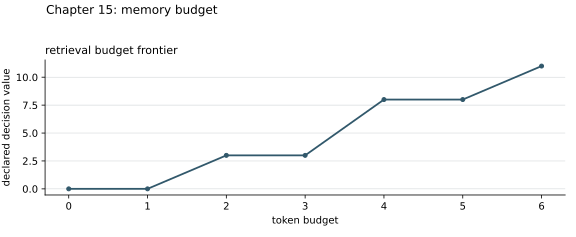

In [3]:
display(SVG(figure_svg(report)))

**Figure 15.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

Additive record values can overcount redundant memories. Two records that repeat the same fact may contribute less together than the sum of their isolated values. This implementation declares additivity rather than inventing a submodular or semantic model. If redundancy matters, provide a different valuation experiment.

The authority boundary is equally important. A remembered instruction does not become authorized because it is recent, highly ranked, or compressed into a confident summary. Version checks preserve a limited current-state contract; broader permissions still need a live authority check.

Compression can also preserve today's action while destroying tomorrow's distinction. The argmax diagnostic is task-relative. Test novel decisions and changed state before claiming sufficient memory. Keep excluded-record reasons in the report so token scarcity is not mistaken for intentional retention of unsafe evidence.

Chapter 15: memory-budget
Which memories deserve a limited retrieval budget, and does compression preserve the decision?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "retrieved_ids": [
    "summary"
  ],
  "retrieval_value": 3.0,
  "tokens_used": 2,
  "excluded_ids": [
    "old-review"
  ],
  "compression_preserves_action": false,
  "original_action": 1,
  "compressed_action": 0
}

Interpretation:
Retrieval optimizes declared decision value among records that satisfy freshness and version-bound authority checks. Compression is checked by the action it preserves.

Assumptions:
- Record values are additive and supplied, not inferred from text similarity.
- Exact finite subset search; no semantic embedding model.

Limitations:
- Preserving one decision vector does not prove sufficiency for every future task.
- Retrieval relevance is not authority.

Execution: completed locally; constructed inputs are not deployment measurements.


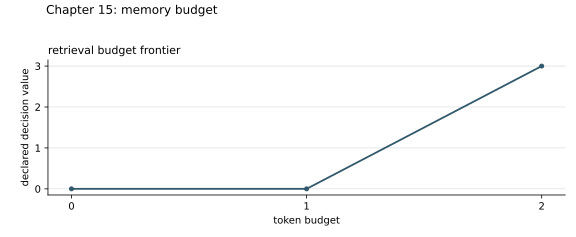

In [4]:
changed_inputs = {'budget': 2,
 'now': 10,
 'current_version': 'v2',
 'records': [{'id': 'review-v2',
              'tokens': 4,
              'decision_value': 8,
              'timestamp': 9,
              'ttl': 3,
              'authority': True,
              'version': 'v2'},
             {'id': 'summary',
              'tokens': 2,
              'decision_value': 3,
              'timestamp': 8,
              'ttl': 5,
              'authority': False,
              'version': 'v1'},
             {'id': 'old-review',
              'tokens': 1,
              'decision_value': 100,
              'timestamp': 9,
              'ttl': 3,
              'authority': True,
              'version': 'v1'}],
 'original_action_values': [4, 6],
 'compressed_action_values': [6, 5]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 15.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer case excludes expired even though it is cheap and valuable. Current is fresh, version-valid, and consumes the full budget 3, so it is selected with value 4. Both supplied decision vectors prefer action 0, preserving this action under compression.

For local use, attach timestamps and document versions to records when those affect authority. Give decision values an explicit source, such as a constructed study or measured task benefit. A retrieval recommendation should name records to retain, records to exclude, and the evidence needed to justify their values. Use separate trace analysis when memory is trying to promote untrusted data into control.

In [5]:
transfer_inputs = {'budget': 3,
 'now': 20,
 'current_version': 'doc-C',
 'records': [{'id': 'expired',
              'tokens': 1,
              'decision_value': 10,
              'timestamp': 10,
              'ttl': 2,
              'authority': False,
              'version': 'doc-C'},
             {'id': 'current',
              'tokens': 3,
              'decision_value': 4,
              'timestamp': 19,
              'ttl': 3,
              'authority': True,
              'version': 'doc-C'}],
 'original_action_values': [1, 0],
 'compressed_action_values': [2, 1]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 15: memory-budget
Which memories deserve a limited retrieval budget, and does compression preserve the decision?
Evidence: constructed transfer example

Calculated quantities:
{
  "retrieved_ids": [
    "current"
  ],
  "retrieval_value": 4.0,
  "tokens_used": 3,
  "excluded_ids": [
    "expired"
  ],
  "compression_preserves_action": true,
  "original_action": 0,
  "compressed_action": 0
}

Interpretation:
Retrieval optimizes declared decision value among records that satisfy freshness and version-bound authority checks. Compression is checked by the action it preserves.

Assumptions:
- Record values are additive and supplied, not inferred from text similarity.
- Exact finite subset search; no semantic embedding model.

Limitations:
- Preserving one decision vector does not prove sufficiency for every future task.
- Retrieval relevance is not authority.

Execution: completed locally; constructed inputs are not deployment measurements.


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **budget:** Nonnegative integer token budget up to 10000.
- **now:** Nonnegative current time.
- **current_version:** Current document or state version identifier.
- **records:** At most 20 records. Each has id,tokens:positive integer,decision_value:nonnegative number,timestamp,ttl:nonnegative numbers,authority:boolean,version:string.
- **original_action_values:** Finite values for each original decision alternative.
- **compressed_action_values:** Aligned values after compression.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch15.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 15: memory-budget
Which memories deserve a limited retrieval budget, and does compression preserve the decision?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "retrieved_ids": [
    "current"
  ],
  "retrieval_value": 4.0,
  "tokens_used": 3,
  "excluded_ids": [
    "expired"
  ],
  "compression_preserves_action": true,
  "original_action": 0,
  "compressed_action": 0
}

Interpretation:
Retrieval optimizes declared decision value among records that satisfy freshness and version-bound authority checks. Compression is checked by the action it preserves.

Assumptions:
- Record values are additive and supplied, not inferred from text similarity.
- Exact finite subset search; no semantic embedding model.

Limitations:
- Preserving one decision vector does not prove sufficiency for every future task.
- Retrieval relevance is not authority.

Execution: completed locally; constructed inputs are not deployment measurements.


## Questions

1. Why exclude old-review?

2. What is default retrieval value?

3. Does action preservation prove all future information survives?

Answers: [separate solutions](../solutions/ch15.md). Try the calculation before opening them.

## Summary

Memory selection is a decision under cost, freshness, and authority. Exact knapsack allocation chooses among eligible records; action comparison checks a limited compression property. The obsolete approval is excluded despite its high value, the changed budget reduces retrieval, and changed compression reverses the action. These calculations do not perform semantic retrieval or establish universal sufficiency. Preserve the valuation and version contract whenever memory influences an action.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-15-memory-budget`](../skills/maa-15-memory-budget/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 15.1

![Equation 15.1](../assets/math/f7d464531063a86995f9.svg)

Equation (15.1) selects records by expected decision value under a stated context budget.

Include records only when expected decision improvement exceeds the decision-value-priced token cost within budget.

LaTeX source, preserved for inspection:

```latex
R^\star\in\arg\max_{R:\,\sum_{m\in R}c(m)\le B}
\left\{\operatorname E[\text{decision value}\mid R]-\lambda\sum_{m\in R}c(m)\right\}.
\tag{15.1}
```